# Step 1: Importing Libraries


In [1]:
# Importing essential libraries for data analysis, visualization, preprocessing, and model building
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
import joblib

In [2]:
# Loading the heart failure dataset into a pandas DataFrame
Dataset = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [1]:
Dataset

NameError: name 'Dataset' is not defined

In [4]:
Dataset.head(35)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.90,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.10,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.30,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.90,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.70,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.10,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.20,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.10,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.50,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.40,133,1,1,10,1


In [5]:
# Checking the shape of the dataset to understand number of records and features
Dataset.shape

(299, 13)

In [6]:
# Verifying if there are any duplicate records in the dataset
Dataset.duplicated().sum()

np.int64(0)

In [7]:
# Displaying data types and non-null counts of all columns to check for data quality and missing values
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [8]:
# Generating summary statistics (count, mean, std, min, max, etc.) for each numerical column to understand data distribution
Dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


<Axes: ylabel='Frequency'>

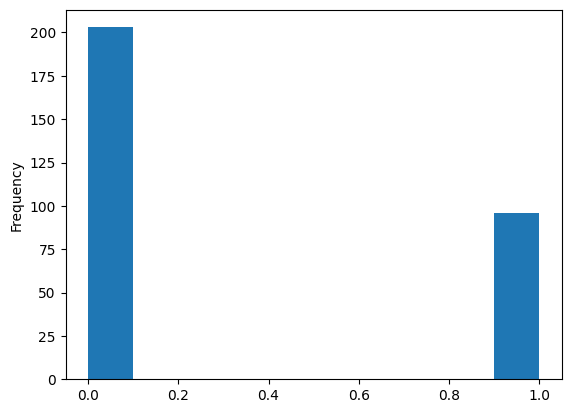

In [9]:
# Plotting a histogram to visualize the distribution of the target variable 'DEATH_EVENT'
Dataset['DEATH_EVENT'].plot(kind='hist')

<Axes: xlabel='DEATH_EVENT'>

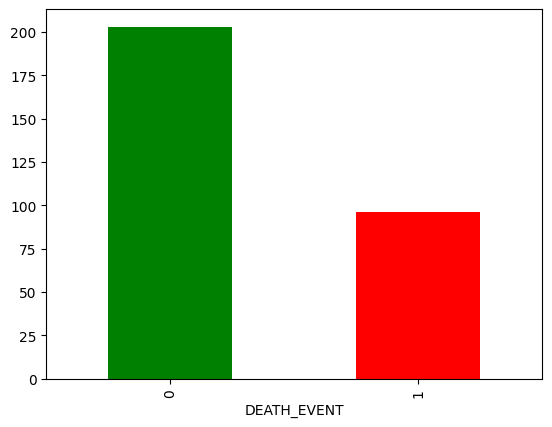

In [10]:
# Plotting a bar chart to show count of each class in 'DEATH_EVENT'
Dataset['DEATH_EVENT'].value_counts().plot(kind='bar', color=['green', 'red'])

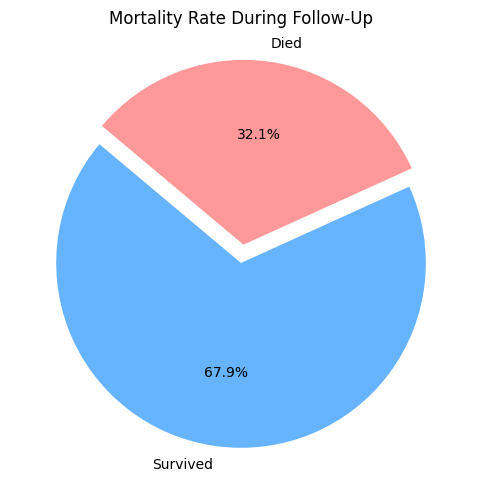

In [11]:
# Counting occurrences of each class in the target variable 'DEATH_EVENT'
death_counts = Dataset["DEATH_EVENT"].value_counts()

# Defining labels and colors for the pie chart (0 = Survived, 1 = Died)
labels = ['Survived', 'Died']
colors = ['#66b3ff', '#ff9999']

# Creating a pie chart to visualize the proportion of survivors vs deaths
plt.figure(figsize=(6, 6))
plt.pie(death_counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0, 0.1))

# Adding a title and displaying the pie chart
plt.title("Mortality Rate During Follow-Up")
plt.show()


# Step 2:EDA

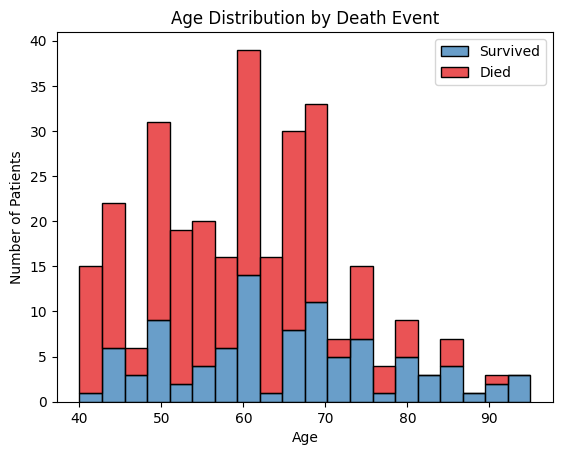

In [12]:
# Stacked histogram to visualize age distribution across survival statusplt.figure(figsize=(8, 5))
sns.histplot(data=Dataset, x="age", hue="DEATH_EVENT", multiple="stack", bins=20, palette="Set1")
plt.title("Age Distribution by Death Event")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.legend(["Survived", "Died"])
plt.show()

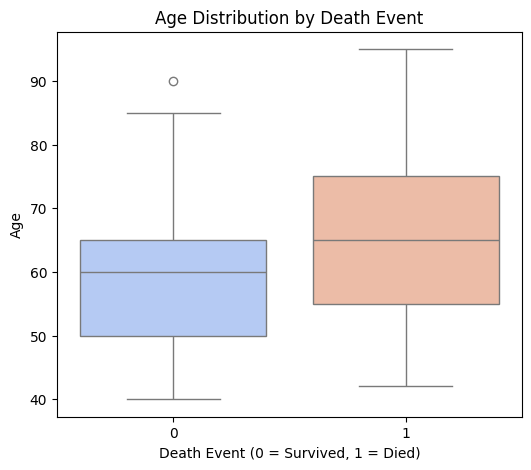

In [13]:
# Boxplot to compare age distribution between survivors and deceased patients
plt.figure(figsize=(6, 5))
sns.boxplot(x='DEATH_EVENT', y='age', data=Dataset, hue='DEATH_EVENT', palette='coolwarm', legend=False)
plt.title("Age Distribution by Death Event")
plt.xlabel("Death Event (0 = Survived, 1 = Died)")
plt.ylabel("Age")
plt.show()


In [14]:
def visualize_mortality_by_time_period(Dataset):
    """Plot mortality rate and patient distribution across follow-up time periods"""

    # Step 1: Create time intervals
    Dataset['time_period'] = pd.cut(Dataset['time'], 
                                    bins=[0, 50, 100, 150, 200, 300], 
                                    labels=['0-50 days', '51-100 days', '101-150 days', 
                                            '151-200 days', '200+ days'])

    # Step 2: Calculate mortality rate by time period
    mortality_by_period = Dataset.groupby('time_period')['DEATH_EVENT'].agg(['count', 'sum', 'mean'])
    mortality_by_period.columns = ['Total_Patients', 'Deaths', 'Mortality_Rate']

    # Step 3: Visualization
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Mortality rate
    mortality_by_period['Mortality_Rate'].plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Mortality Rate by Follow-up Period')
    axes[0].set_ylabel('Mortality Rate')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: Stacked bar for outcomes
    time_outcome = Dataset.groupby(['time_period', 'DEATH_EVENT']).size().unstack(fill_value=0)
    time_outcome.plot(kind='bar', stacked=True, ax=axes[1], color=['skyblue', 'red'])
    axes[1].set_title('Patient Distribution by Follow-up Period')
    axes[1].set_ylabel('Number of Patients')
    axes[1].legend(['Survived', 'Died'])
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return mortality_by_period


C:\Users\singh\AppData\Local\Temp\ipykernel_28564\199296297.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_by_period = Dataset.groupby('time_period')['DEATH_EVENT'].agg(['count', 'sum', 'mean'])
C:\Users\singh\AppData\Local\Temp\ipykernel_28564\199296297.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_outcome = Dataset.groupby(['time_period', 'DEATH_EVENT']).size().unstack(fill_value=0)


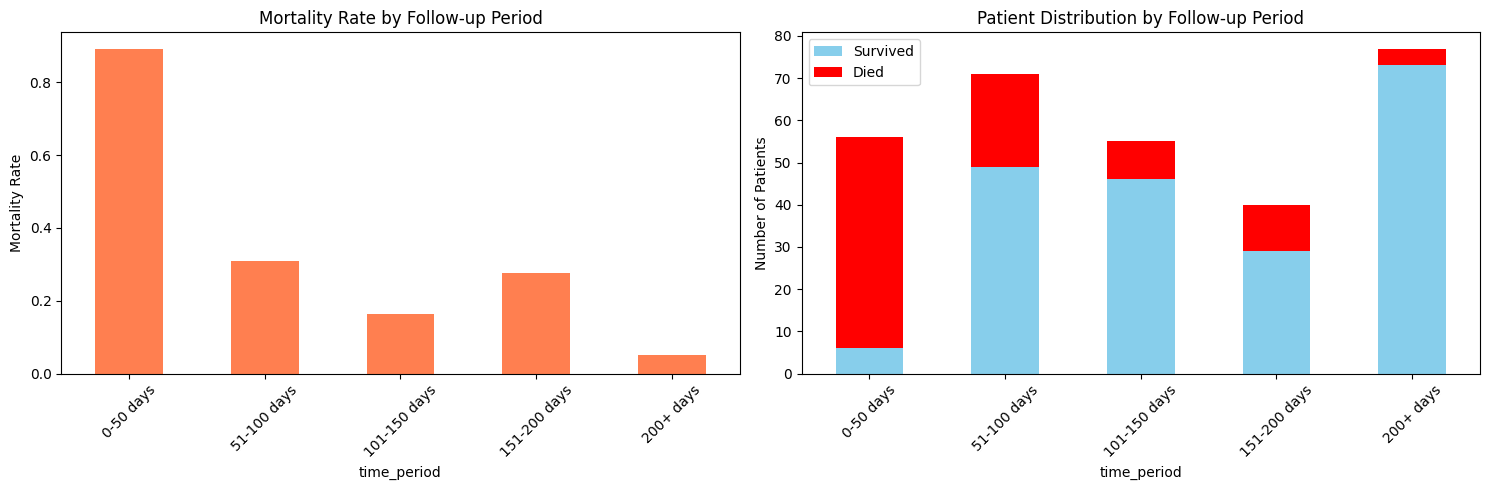

In [15]:
mortality_stats = visualize_mortality_by_time_period(Dataset)


In [16]:
# Calculating percentage of patients who died (DEATH_EVENT == 1)
death_percentage = Dataset['DEATH_EVENT'].mean() * 100
print(f"Approximately {death_percentage:.2f}% of patients died during follow-up.")


Approximately 32.11% of patients died during follow-up.


In [17]:
# Calculating average age for survivors and deceased patients
mean_age_by_death = Dataset.groupby('DEATH_EVENT')['age'].mean()
print("Average age of survivors:", round(mean_age_by_death[0], 2))
print("Average age of deceased:", round(mean_age_by_death[1], 2))


Average age of survivors: 58.76
Average age of deceased: 65.22


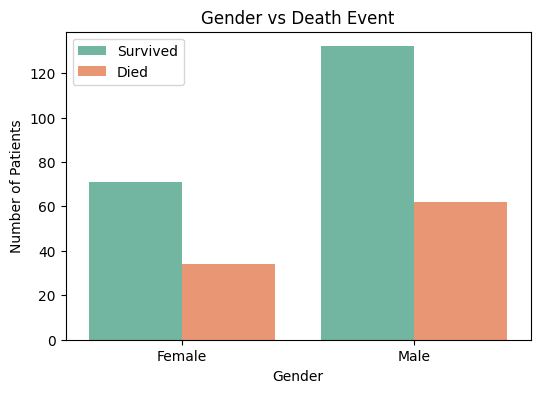

In [18]:
# Countplot to visualize gender distribution across survival status
# Helps analyze if gender has any influence on patient mortality
plt.figure(figsize=(6, 4))
sns.countplot(data=Dataset, x="sex", hue="DEATH_EVENT", palette="Set2")
plt.title("Gender vs Death Event")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(["Survived", "Died"])
plt.show()

In [19]:
# Calculate death rate by gender
death_rate_by_gender = Dataset.groupby('sex')['DEATH_EVENT'].mean() * 100
print(death_rate_by_gender)

sex
0    32.380952
1    31.958763
Name: DEATH_EVENT, dtype: float64


In [20]:
# Counting the number of male and female patients in each DEATH_EVENT group
# Helps in understanding if one gender is more likely to die than the other
Dataset.groupby('DEATH_EVENT')['sex'].value_counts()

DEATH_EVENT  sex
0            1      132
             0       71
1            1       62
             0       34
Name: count, dtype: int64

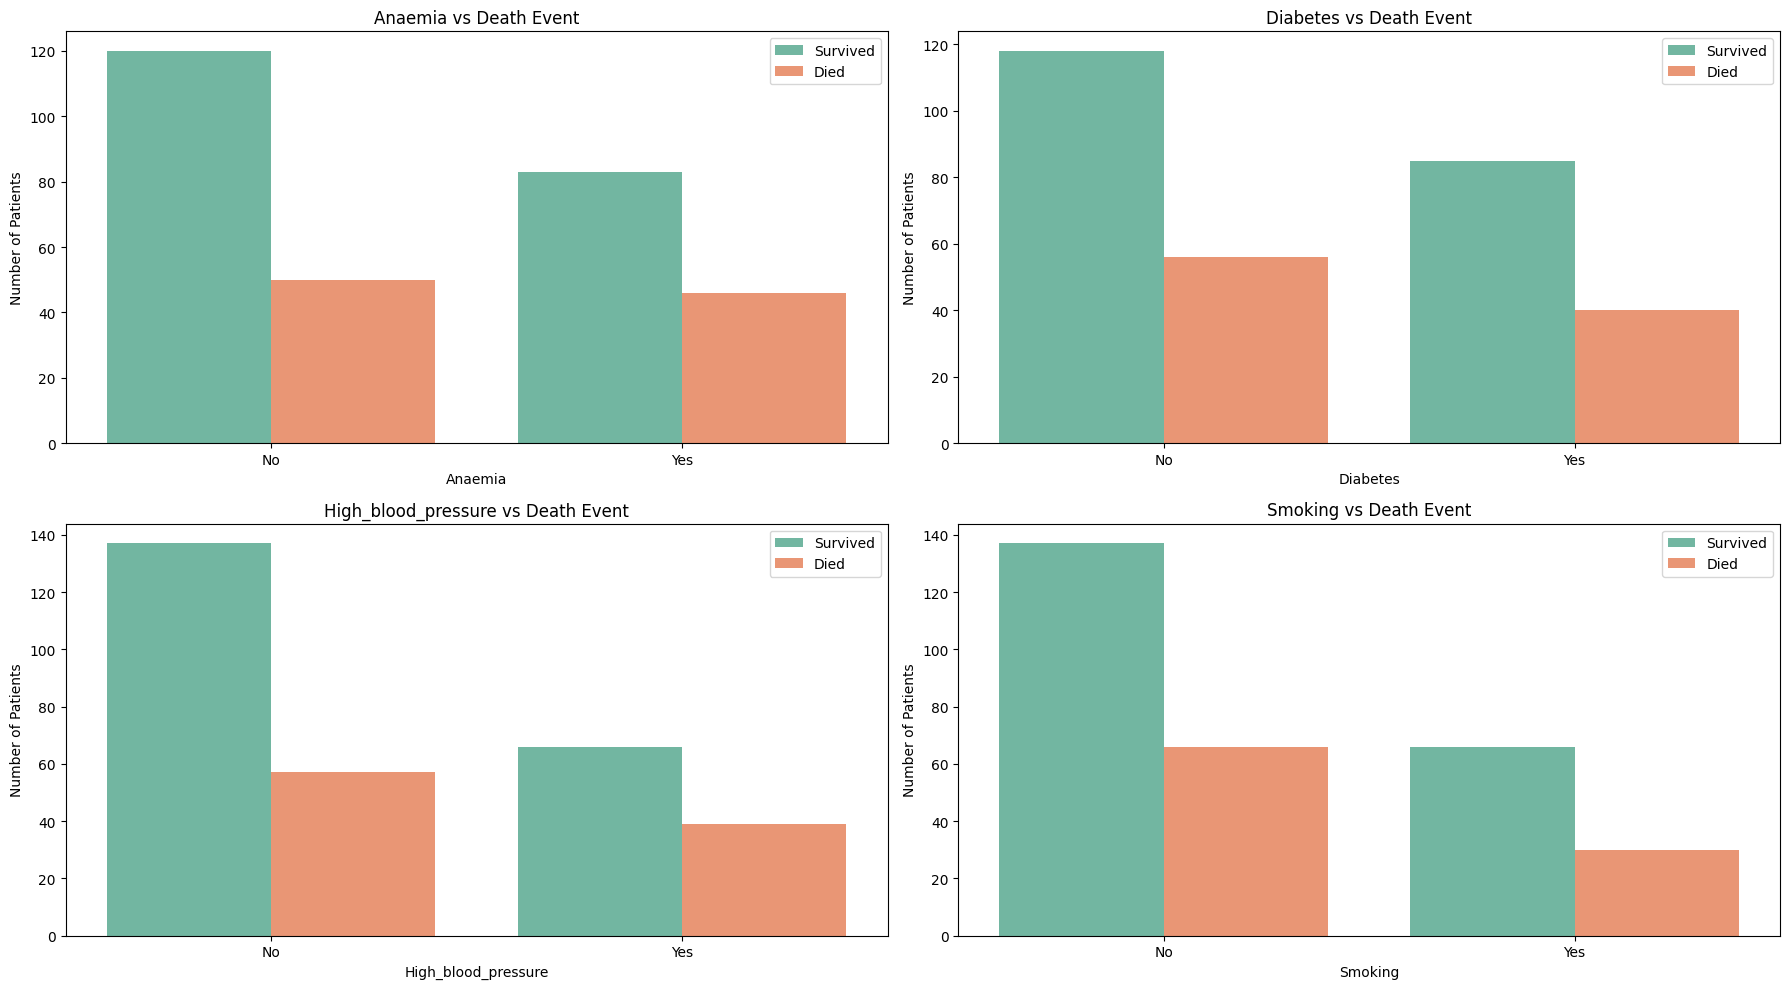

In [21]:
# Plotting categorical features against DEATH_EVENT to explore their impact on mortality
# Each subplot shows how the presence or absence of a condition relates to patient survival
cat_features = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

plt.figure(figsize=(18, 10))
for i, feature in enumerate(cat_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=Dataset, x=feature, hue="DEATH_EVENT", palette="Set2")
    plt.title(f"{feature.capitalize()} vs Death Event")
    plt.xlabel(feature.capitalize())
    plt.ylabel("Number of Patients")
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.legend(["Survived", "Died"])

plt.tight_layout()
plt.show()

In [22]:
# Mortality rate for each categorical feature
for feature in cat_features:
    rate = Dataset.groupby(feature)['DEATH_EVENT'].mean() * 100
    print(f"\nMortality rate by {feature}:")
    print(rate)


Mortality rate by anaemia:
anaemia
0    29.411765
1    35.658915
Name: DEATH_EVENT, dtype: float64

Mortality rate by diabetes:
diabetes
0    32.183908
1    32.000000
Name: DEATH_EVENT, dtype: float64

Mortality rate by high_blood_pressure:
high_blood_pressure
0    29.381443
1    37.142857
Name: DEATH_EVENT, dtype: float64

Mortality rate by smoking:
smoking
0    32.512315
1    31.250000
Name: DEATH_EVENT, dtype: float64


In [23]:
Dataset.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,time_period
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1,0-50 days
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1,0-50 days
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1,0-50 days
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1,0-50 days
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1,0-50 days


In [24]:
# Counting how many patients have high blood pressure (1) vs. those who do not (0)
Dataset['high_blood_pressure'].value_counts()

high_blood_pressure
0    194
1    105
Name: count, dtype: int64

In [25]:
# Checking how many patients had each specific follow-up duration (in days)
# Helps understand the distribution of follow-up time across the dataset
Dataset['time'].value_counts()

time
187    7
250    7
10     6
107    6
186    6
      ..
257    1
271    1
278    1
280    1
285    1
Name: count, Length: 148, dtype: int64

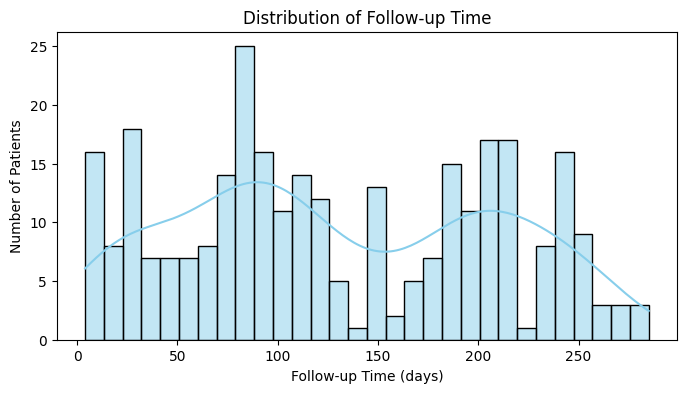

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(Dataset['time'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Follow-up Time")
plt.xlabel("Follow-up Time (days)")
plt.ylabel("Number of Patients")
plt.show()

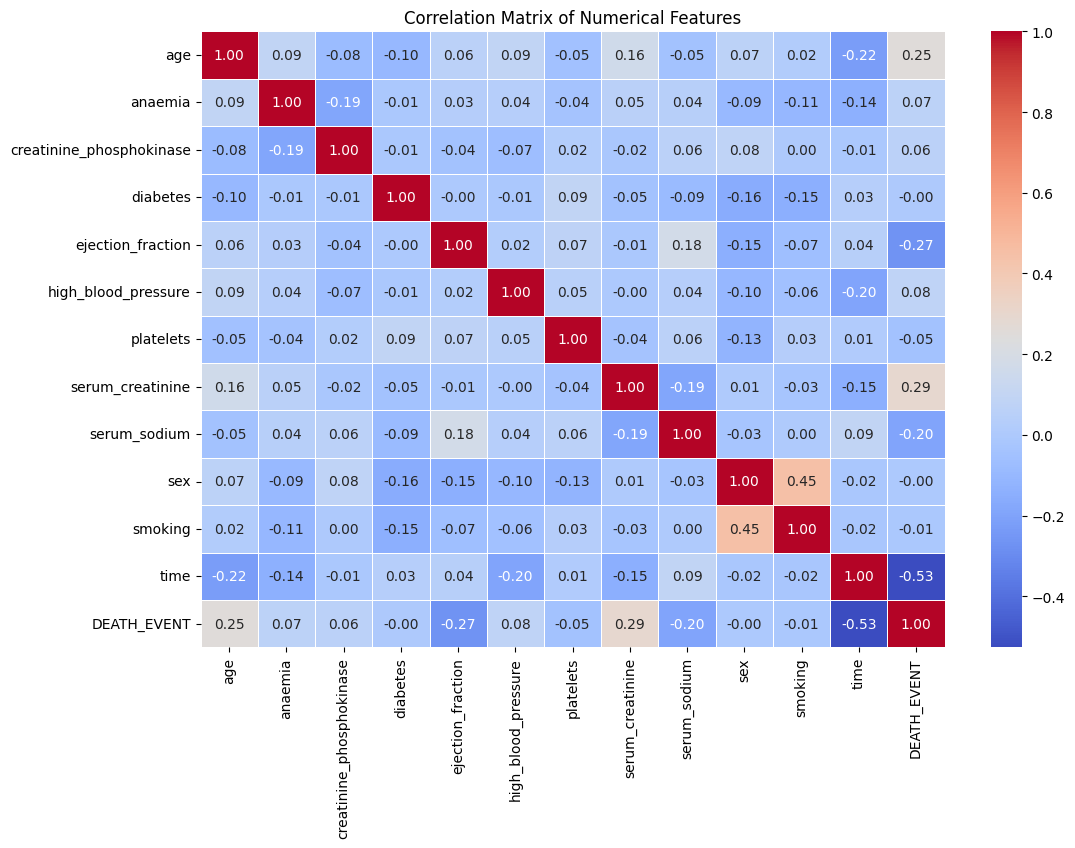

In [27]:
# Select only numeric columns to avoid errors with categorical columns
corr_matrix = Dataset.select_dtypes(include='number').corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


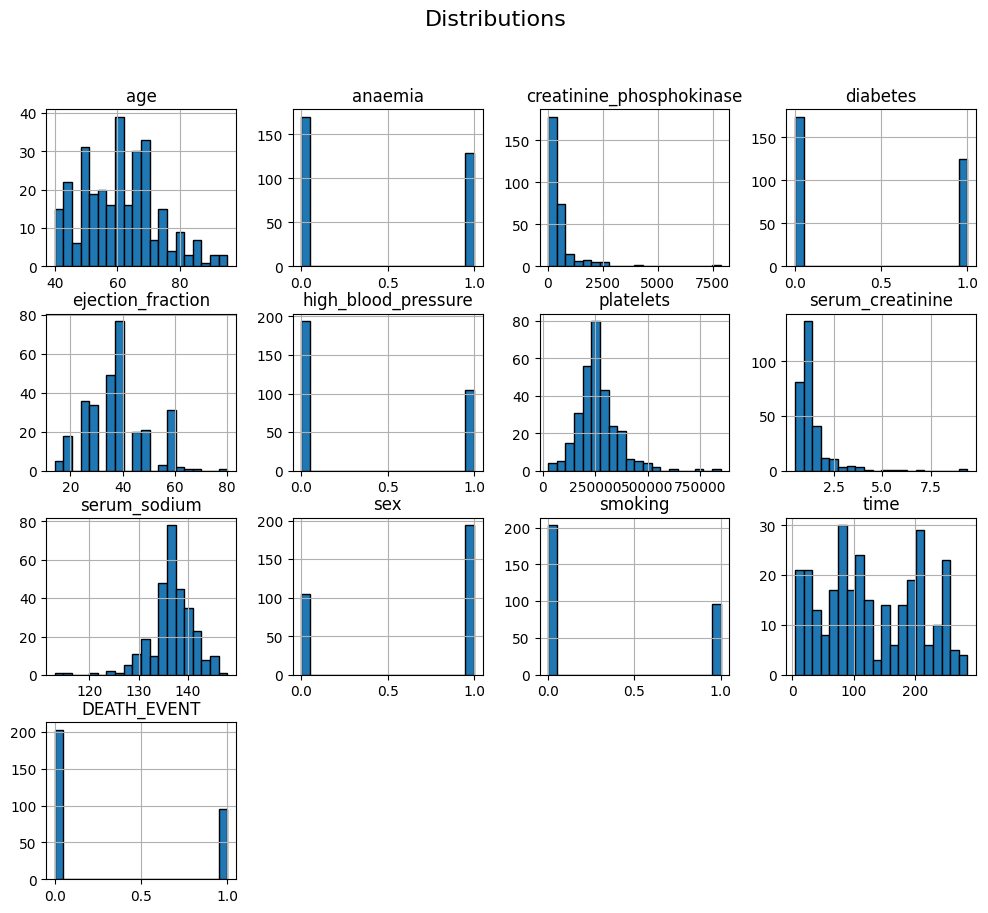

In [28]:
# Distributions
# Plotting histograms for all numerical features to observe their distributions
# Useful for detecting skewness, outliers, and understanding feature scaling requirements
Dataset.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Distributions', fontsize=16)
plt.show()

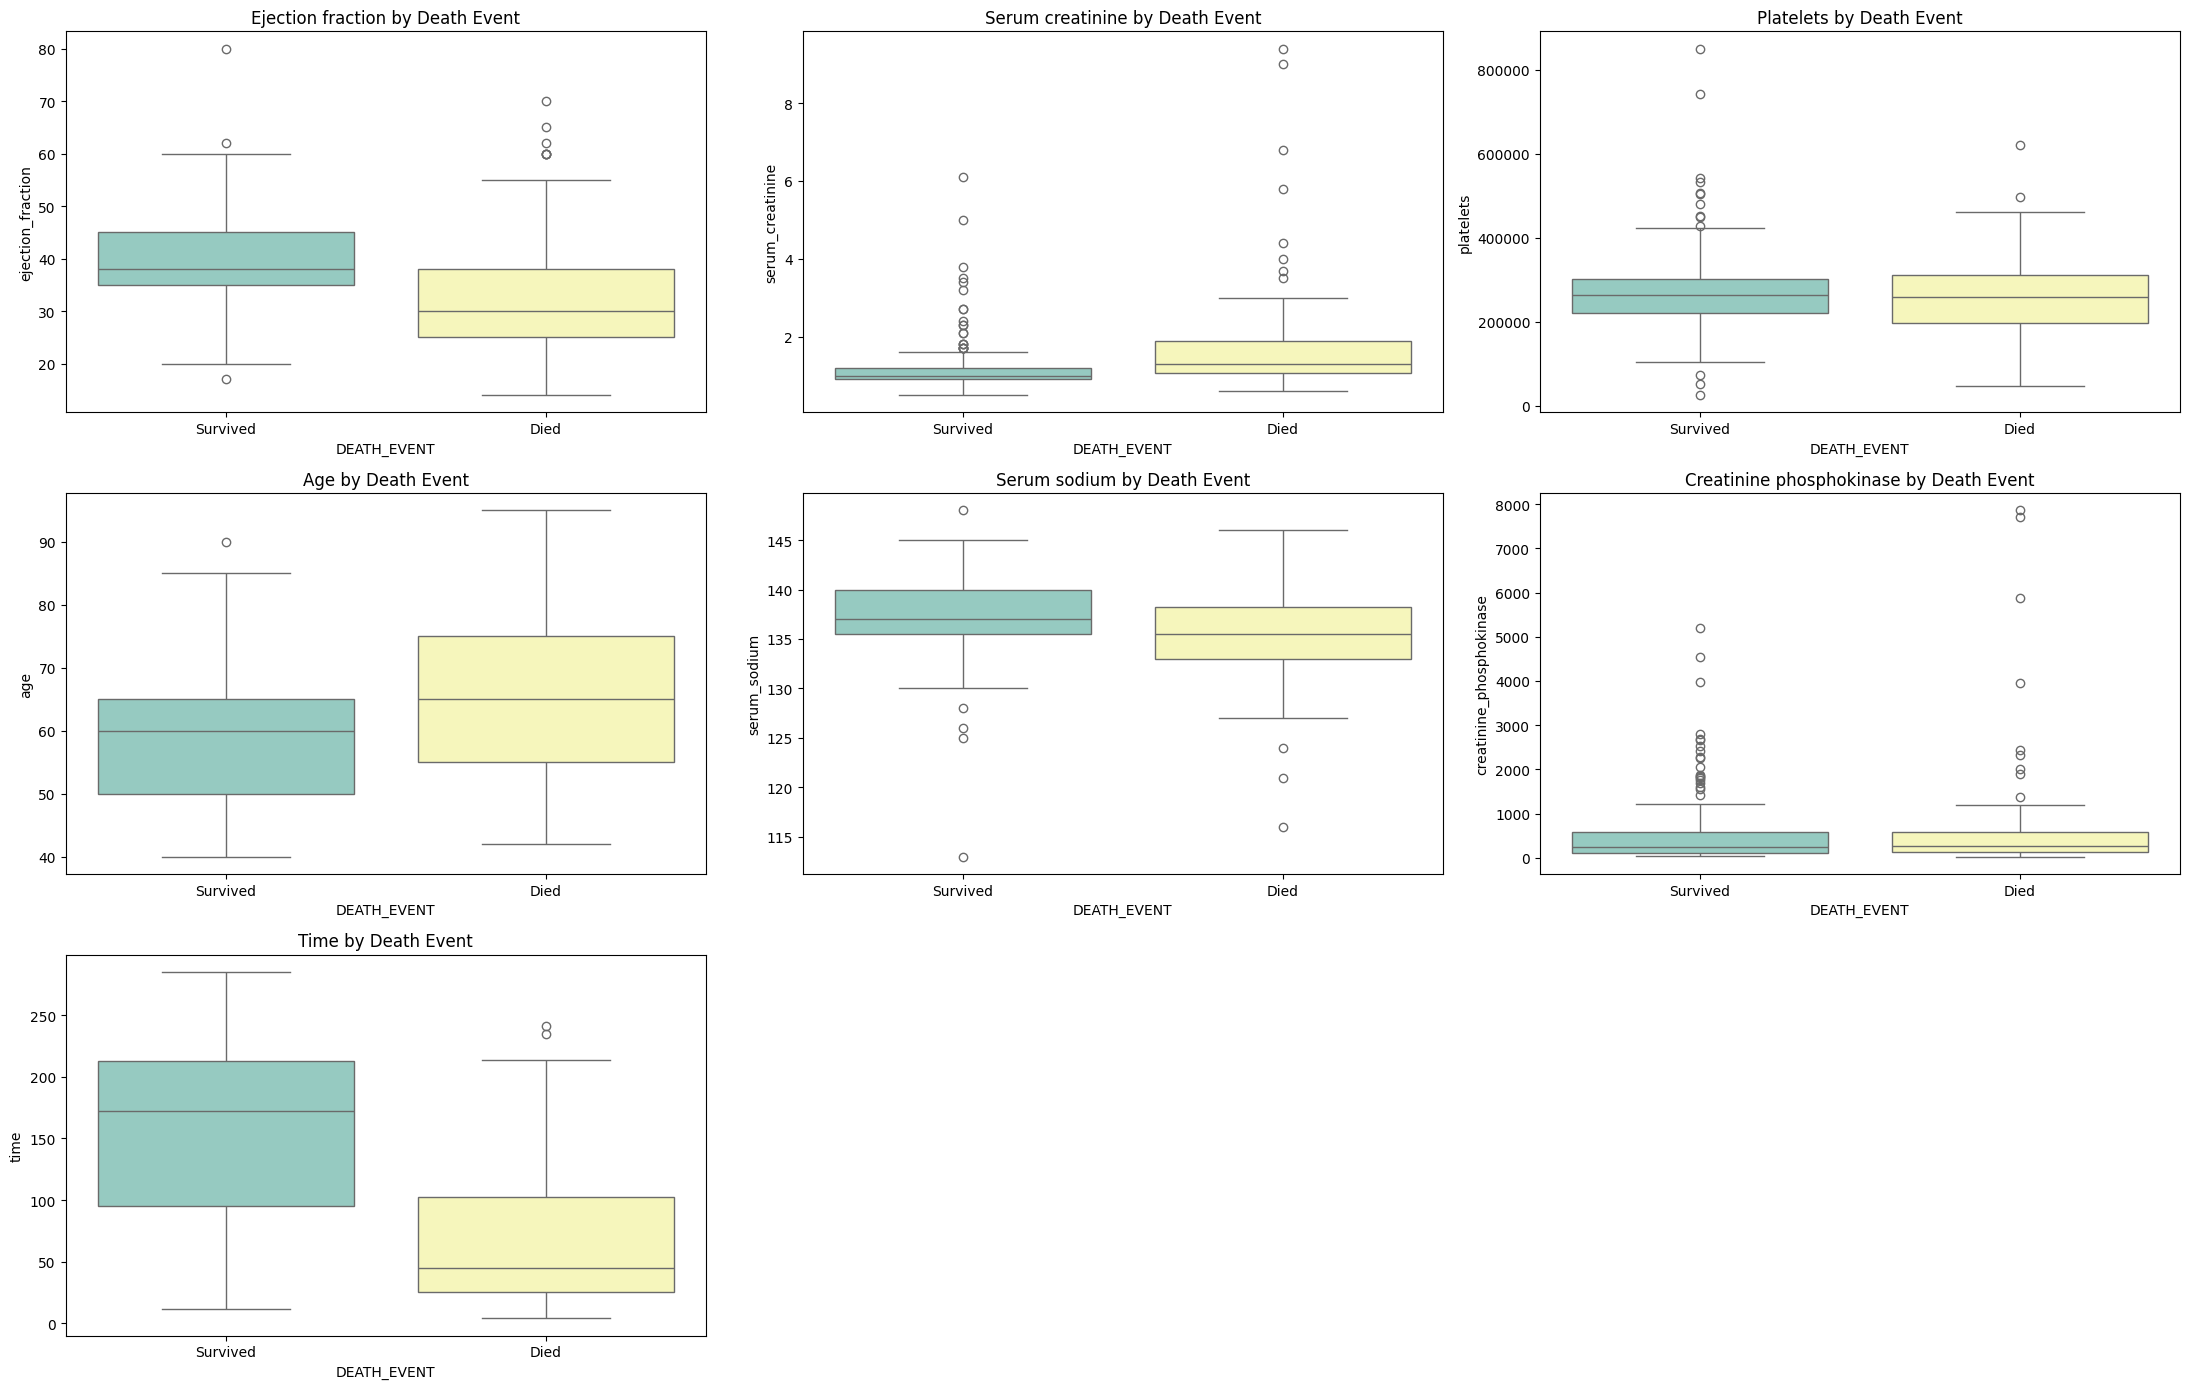

In [29]:
# Using boxplots to compare the distribution of continuous features for survived vs. deceased patients
# This helps identify features that show significant differences based on mortality
# Outliers and median shifts are easy to spot using this method
cont_features = [
    "ejection_fraction", "serum_creatinine", "platelets",
    "age", "serum_sodium", "creatinine_phosphokinase", "time"
]

plt.figure(figsize=(22, 14))
for i, feature in enumerate(cont_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=Dataset, x="DEATH_EVENT", y=feature, hue="DEATH_EVENT", palette="Set3", legend=False)
    plt.title(f"{feature.replace('_', ' ').capitalize()} by Death Event")
    plt.xticks([0, 1], ['Survived', 'Died'])

plt.tight_layout()
plt.show()

# Step 3:Handling Outliers

In [30]:
# Function to cap outliers using IQR method (Tukey's rule)
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # First quartile
    Q3 = df[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Interquartile range
    lower = Q1 - 1.5 * IQR  # Lower bound
    upper = Q3 + 1.5 * IQR  # Upper bound
    
    # Cap values below lower bound and above upper bound
    df[column] = df[column].apply(lambda x: lower if x < lower else upper if x > upper else x)
    return df

# Columns that may contain outliers
cols_with_outliers = ['serum_creatinine', 'creatinine_phosphokinase', 'platelets']

# Apply outlier capping to each of the selected columns
for col in cols_with_outliers:
    Dataset = cap_outliers(Dataset, col)


In [31]:
Dataset

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,time_period
0,75.0,0,582.00,0,20,1,265000.00,1.90,130,1,0,4,1,0-50 days
1,55.0,0,1280.25,0,38,0,263358.03,1.10,136,1,0,6,1,0-50 days
2,65.0,0,146.00,0,20,0,162000.00,1.30,129,1,1,7,1,0-50 days
3,50.0,1,111.00,0,20,0,210000.00,1.90,137,1,0,7,1,0-50 days
4,65.0,1,160.00,1,20,0,327000.00,2.15,116,0,0,8,1,0-50 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61.00,1,38,1,155000.00,1.10,143,1,1,270,0,200+ days
295,55.0,0,1280.25,0,38,0,270000.00,1.20,139,0,0,271,0,200+ days
296,45.0,0,1280.25,1,60,0,440000.00,0.80,138,0,0,278,0,200+ days
297,45.0,0,1280.25,0,38,0,140000.00,1.40,140,1,1,280,0,200+ days


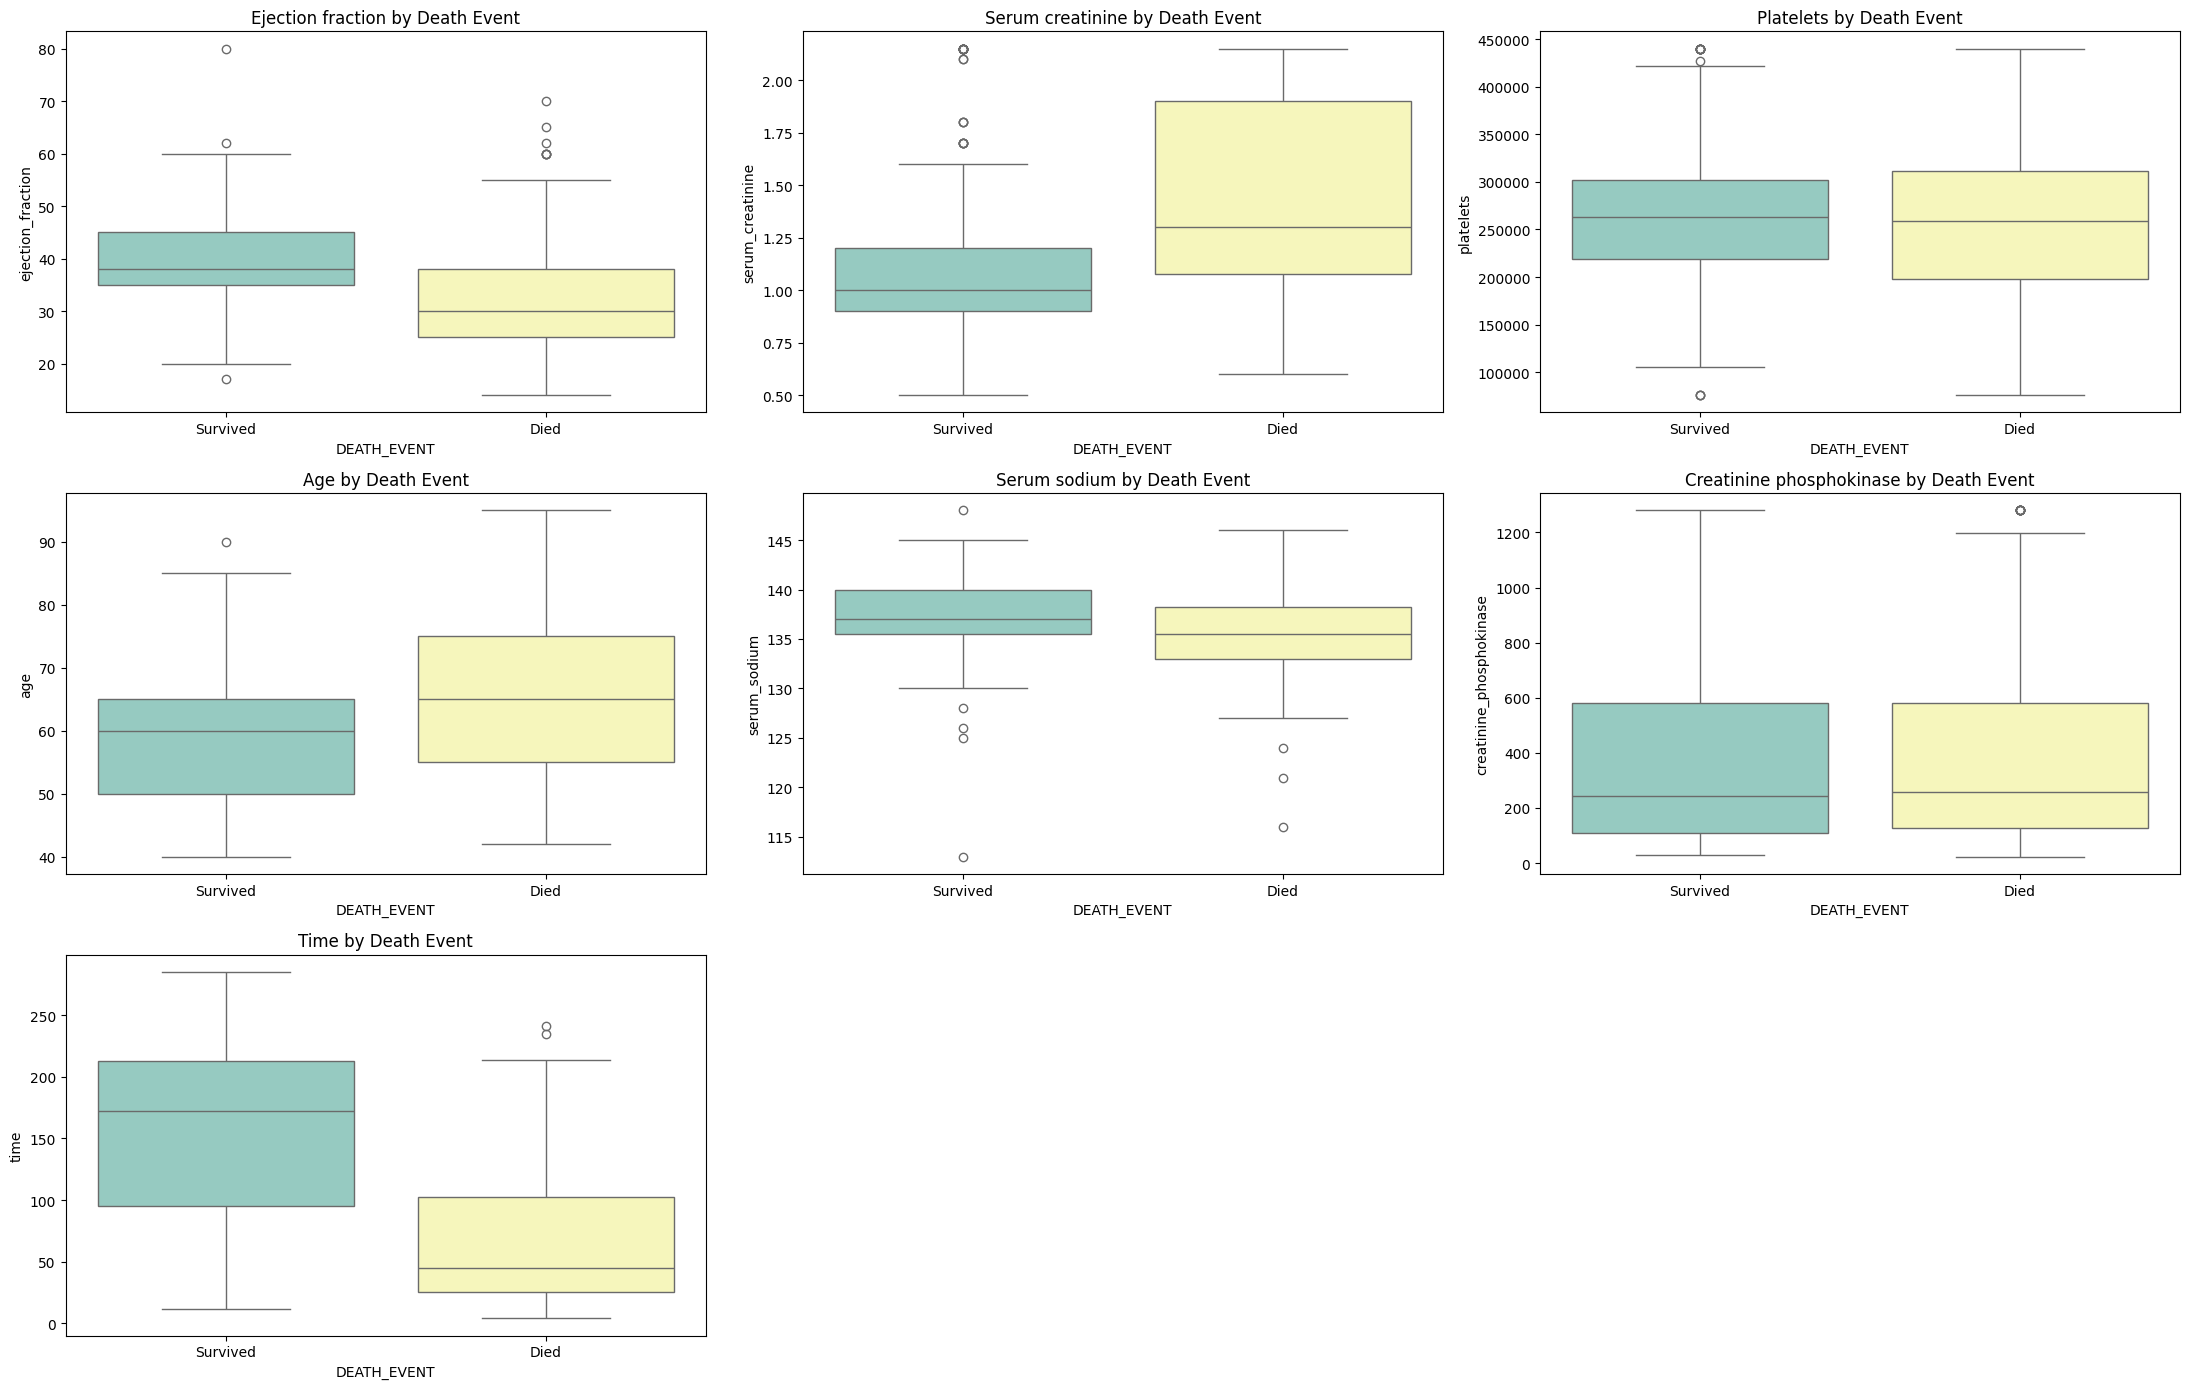

In [32]:
cont_features = [
    "ejection_fraction", "serum_creatinine", "platelets",
    "age", "serum_sodium", "creatinine_phosphokinase", "time"
]

plt.figure(figsize=(22, 14))
for i, feature in enumerate(cont_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=Dataset, x="DEATH_EVENT", y=feature, hue="DEATH_EVENT", palette="Set3", legend=False)
    plt.title(f"{feature.replace('_', ' ').capitalize()} by Death Event")
    plt.xticks([0, 1], ['Survived', 'Died'])

plt.tight_layout()
plt.show()

# Step 4:Spliting Data

In [33]:
# x will contain all the columns except 'DEATH_EVENT'
x = Dataset.drop('DEATH_EVENT', axis=1)

# y will contain only the 'DEATH_EVENT' column which we are trying to predict
y = Dataset['DEATH_EVENT']

In [34]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [35]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((239, 13), (60, 13), (239,), (60,))

In [36]:
# Reset the index to avoid index mismatch or carryover from the original dataset
x_train = x_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Step 5:Balancing Data

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x_train['time_period'] = le.fit_transform(x_train['time_period'])


In [38]:
# SMOTE (Synthetic Minority Oversampling Technique) is applied to the training set
# It generates synthetic examples of the minority class (death = 1) to balance the class distribution

sm = SMOTE(random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)

<Axes: ylabel='Frequency'>

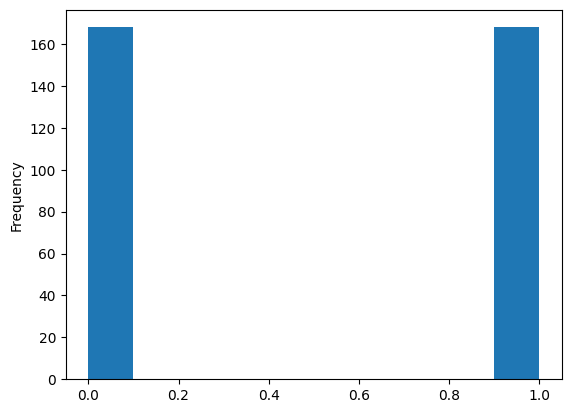

In [39]:
y_train.plot(kind='hist')

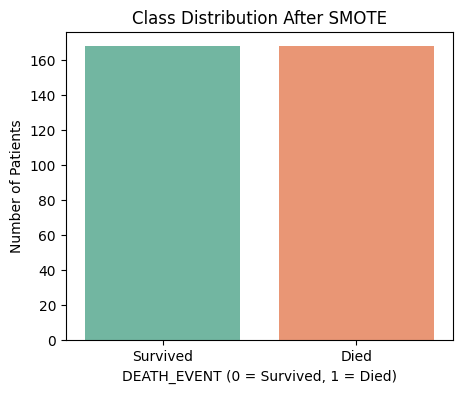

In [40]:
# STEP: Visualizing class distribution after SMOTE

# Convert the class labels into value counts
class_counts = y_train.value_counts()

# Plotting a bar chart for better readability of binary class distribution
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="Set2", legend=False)


plt.title("Class Distribution After SMOTE")
plt.xlabel("DEATH_EVENT (0 = Survived, 1 = Died)")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Survived", "Died"])
plt.show()


In [41]:
# STEP: Check the class distribution in y_train after applying SMOTE (to verify balancing)
y_train.value_counts()

DEATH_EVENT
1    168
0    168
Name: count, dtype: int64

In [42]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((336, 13), (60, 13), (336,), (60,))

In [43]:
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


x_train: (336, 13)
x_test : (60, 13)
y_train: (336,)
y_test : (60,)


In [44]:
y_train.value_counts()

DEATH_EVENT
1    168
0    168
Name: count, dtype: int64

In [45]:
y_test.value_counts()

DEATH_EVENT
0    35
1    25
Name: count, dtype: int64

# Step 6:Feature Importance

time_period                 0.219753
time                        0.204847
serum_creatinine            0.114252
ejection_fraction           0.084894
serum_sodium                0.064925
age                         0.061215
platelets                   0.051613
creatinine_phosphokinase    0.044285
sex                         0.036910
anaemia                     0.030678
smoking                     0.030060
diabetes                    0.029074
high_blood_pressure         0.027494
dtype: float64


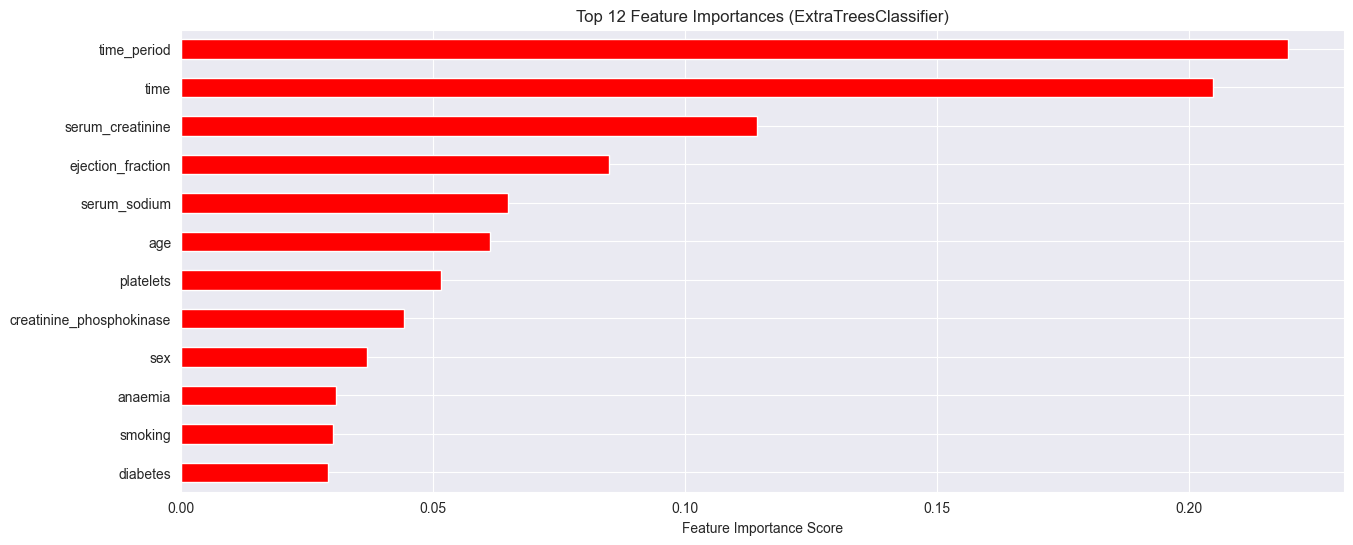

In [46]:

from sklearn.ensemble import ExtraTreesClassifier

# Train the model first
model = ExtraTreesClassifier()
model.fit(x_train, y_train)

# Create a Series with importances
feat_importances = pd.Series(model.feature_importances_, index=x_train.columns)

# Print all importances in descending order
print(feat_importances.sort_values(ascending=False))

# Plot top 12 important features
plt.rcParams['figure.figsize'] = 15, 6
sns.set_style("darkgrid")
feat_importances.nlargest(12).plot(kind='barh', color='red')
plt.title("Top 12 Feature Importances (ExtraTreesClassifier)")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.show()


In [47]:
from sklearn.preprocessing import LabelEncoder

# Convert to string first to ensure uniform type
x_train['time_period'] = x_train['time_period'].astype(str)
x_test['time_period'] = x_test['time_period'].astype(str)

# Combine train and test for consistent label encoding
combined = pd.concat([x_train['time_period'], x_test['time_period']], axis=0)

# Fit encoder on combined string data
le = LabelEncoder()
le.fit(combined)

# Transform
x_train['time_period'] = le.transform(x_train['time_period'])
x_test['time_period'] = le.transform(x_test['time_period'])


In [48]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred, target_names=['0', '1']))

              precision    recall  f1-score   support

           0       0.63      0.94      0.76        35
           1       0.75      0.24      0.36        25

    accuracy                           0.65        60
   macro avg       0.69      0.59      0.56        60
weighted avg       0.68      0.65      0.59        60



In [49]:
x_train.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'time_period'],
      dtype='object')

In [50]:
x_train=x_train[['time','serum_creatinine','ejection_fraction']]

In [51]:
x_test=x_test[['time','serum_creatinine','ejection_fraction']]

In [52]:
x_test.head()

,time,serum_creatinine,ejection_fraction
0,250,2.15,40
1,240,0.90,35
2,129,1.10,30
3,10,2.15,35
4,74,1.20,40


# Step 7:Scalling

In [53]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(x_train)

In [54]:
x_train = pd.DataFrame(data_scaled, columns=x_train.columns, index=x_train.index)

In [55]:
x_test_scaled= scaler.transform(x_test)

In [56]:
x_test=pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

In [57]:
x_test.head()

,time,serum_creatinine,ejection_fraction
0,1.755437,1.984710,0.271699
1,1.627049,-0.937834,-0.160140
2,0.201943,-0.470227,-0.591979
3,-1.325872,1.984710,-0.160140
4,-0.504190,-0.236424,0.271699


In [58]:
from IPython.display import FileLink

In [59]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [60]:
FileLink('scaler.pkl')

C:\Users\singh\OneDrive\Documents\Desktop\Project\Heart faliure prediction\scaler.pkl

# Step 8:Models

In [61]:
models ={
    'LogisticRegression' : LogisticRegression(),
    'GaussianNB' : GaussianNB(),
    'KNN Classifier': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree Classifier': DecisionTreeClassifier( max_depth=13,random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=21, max_depth=10, random_state=42),
    'SVC' : SVC(C=10, gamma=0.0002, kernel='rbf'),
    "XGBClassifier":XGBClassifier(use_label_encoder=False,eval_metric='logloss'),
    'GB': GradientBoostingClassifier( n_estimators=55, learning_rate=0.05 , n_iter_no_change=5,validation_fraction=0.20,random_state=42 ),
    'xgb_model':xgb.XGBClassifier( n_estimators=55,random_state=42)
    
}

In [62]:
best_model = None
best_score = 0  
best_model_name = ""

accuracy = []

for model_name, model in models.items():
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    Recall_test = recall_score(y_test, y_test_pred, average='weighted')
    Precision_test = precision_score(y_test, y_test_pred, average='weighted')
    F1_test = f1_score(y_test, y_test_pred, average='weighted')

    Recall_train = recall_score(y_train, y_train_pred, average='weighted')
    Precision_train = precision_score(y_train, y_train_pred, average='weighted')
    F1_train = f1_score(y_train, y_train_pred, average='weighted')

  
    if Recall_test > best_score:
        best_score = Recall_test
        best_model = model
        best_model_name = model_name

    accuracy.append([
        model_name, acc_train, acc_test,
        Recall_train, Recall_test,
        Precision_train, Precision_test,
        F1_train, F1_test
    ])


df_results = pd.DataFrame(accuracy, columns=[
    "Model", "Accuracy_train", "Accuracy_test",
    "Recall_train", "Recall_test",
    "Precision_train", "Precision_test",
    "F1_train", "F1_test"
], index=models.keys())

df_results.sort_values(by='Recall_test', ascending=False)

C:\Users\singh\OneDrive\Documents\Desktop\Project\Heart faliure prediction\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:01:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy_train,Accuracy_test,Recall_train,Recall_test,Precision_train,Precision_test,F1_train,F1_test
KNN Classifier,KNN Classifier,0.922619,0.816667,0.922619,0.816667,0.923159,0.815972,0.922594,0.816087
xgb_model,xgb_model,0.994048,0.800000,0.994048,0.800000,0.994118,0.799060,0.994047,0.798611
XGBClassifier,XGBClassifier,1.000000,0.800000,1.000000,0.800000,1.000000,0.799060,1.000000,0.798611
GB,GB,0.916667,0.783333,0.916667,0.783333,0.916726,0.782407,0.916664,0.782648
Random Forest Classifier,Random Forest Classifier,0.997024,0.766667,0.997024,0.766667,0.997041,0.765178,0.997024,0.765046
LogisticRegression,LogisticRegression,0.854167,0.733333,0.854167,0.733333,0.854179,0.737374,0.854165,0.734540
GaussianNB,GaussianNB,0.860119,0.733333,0.860119,0.733333,0.860438,0.737374,0.860088,0.734540
Decision Tree Classifier,Decision Tree Classifier,1.000000,0.733333,1.000000,0.733333,1.000000,0.731297,1.000000,0.731481
SVC,SVC,0.854167,0.716667,0.854167,0.716667,0.854280,0.723586,0.854155,0.718342


In [63]:
joblib.dump(best_model, 'KNNclassifier.pkl')

['KNNclassifier.pkl']

In [64]:
FileLink('KNNclassifier.pkl')

C:\Users\singh\OneDrive\Documents\Desktop\Project\Heart faliure prediction\KNNclassifier.pkl

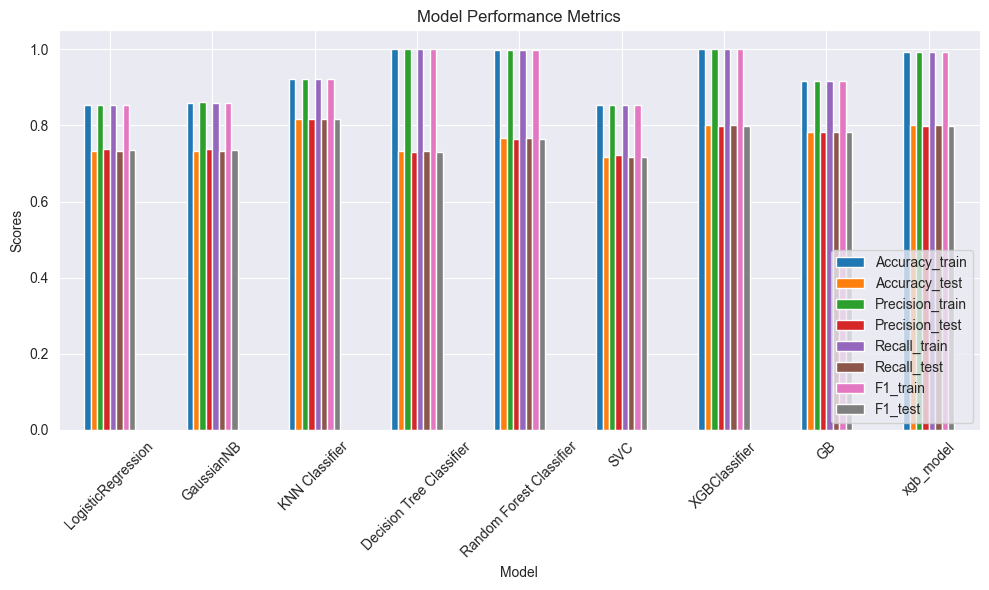

In [65]:
# Plotting model performance metrics for comparison
df_results.plot(
    x='Model',  # X-axis will be the model names
    y=[
        'Accuracy_train', 'Accuracy_test',
        'Precision_train', 'Precision_test',
        'Recall_train', 'Recall_test',
        'F1_train', 'F1_test'
    ],
    kind='bar',         # Bar chart
    figsize=(10, 6)     # Set the size of the figure
)

# Label for X-axis
plt.xlabel('Model')

# Label for Y-axis
plt.ylabel('Scores')

# Title of the plot
plt.title('Model Performance Metrics')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display legend in the lower-right corner
plt.legend(loc='lower right')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()



==================== LogisticRegression ====================


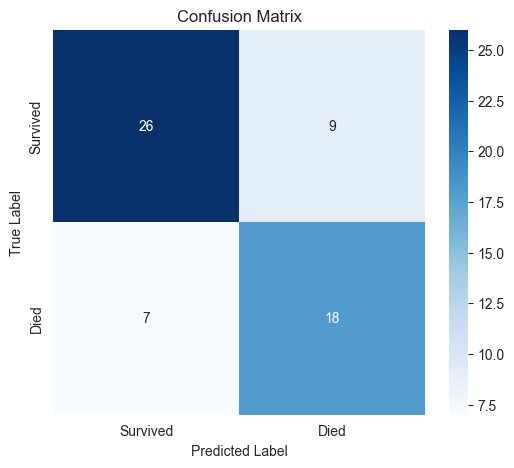


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76        35
           1       0.67      0.72      0.69        25

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60

[[26  9]
 [ 7 18]]

==================== GaussianNB ====================


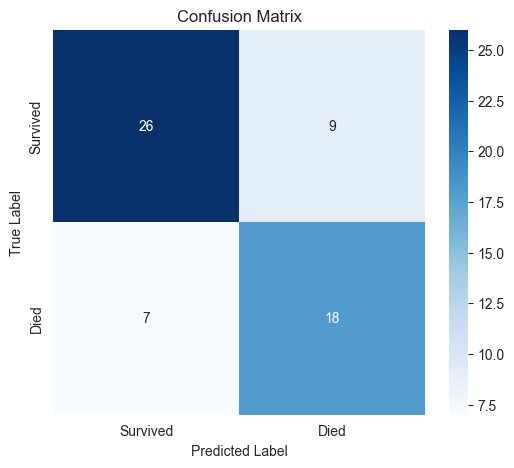


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76        35
           1       0.67      0.72      0.69        25

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60

[[26  9]
 [ 7 18]]

==================== KNN Classifier ====================


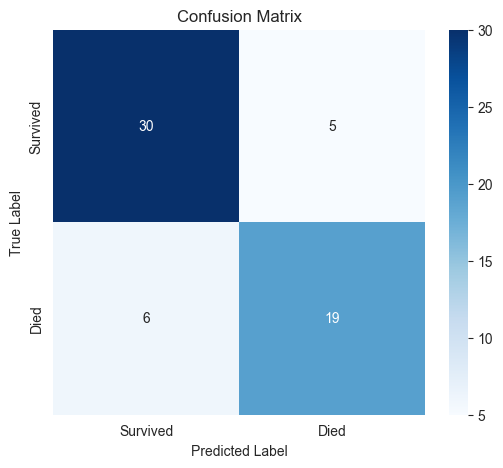


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        35
           1       0.79      0.76      0.78        25

    accuracy                           0.82        60
   macro avg       0.81      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60

[[30  5]
 [ 6 19]]

==================== Decision Tree Classifier ====================


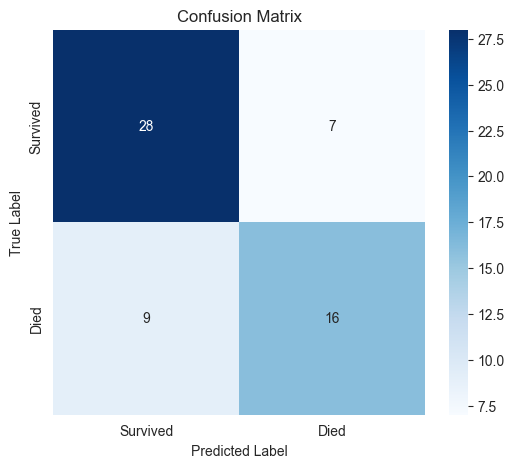


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        35
           1       0.70      0.64      0.67        25

    accuracy                           0.73        60
   macro avg       0.73      0.72      0.72        60
weighted avg       0.73      0.73      0.73        60

[[28  7]
 [ 9 16]]

==================== Random Forest Classifier ====================


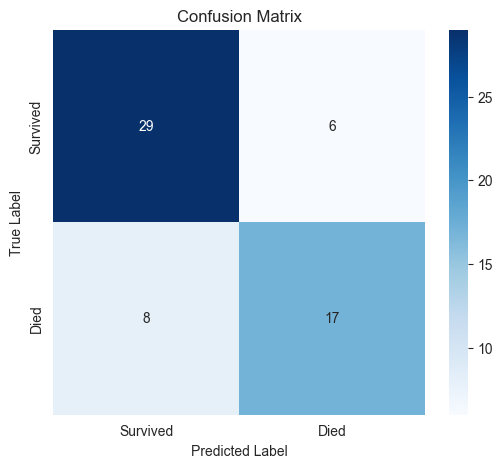


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81        35
           1       0.74      0.68      0.71        25

    accuracy                           0.77        60
   macro avg       0.76      0.75      0.76        60
weighted avg       0.77      0.77      0.77        60

[[29  6]
 [ 8 17]]

==================== SVC ====================


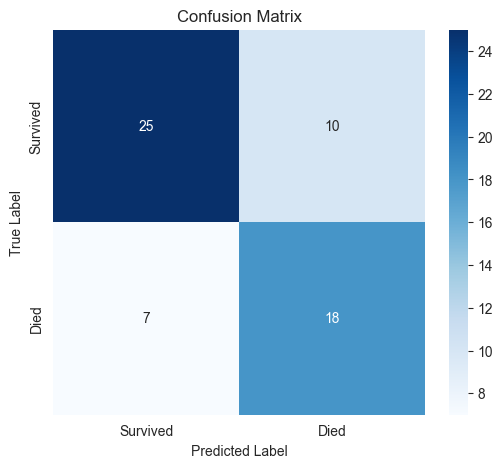


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.71      0.75        35
           1       0.64      0.72      0.68        25

    accuracy                           0.72        60
   macro avg       0.71      0.72      0.71        60
weighted avg       0.72      0.72      0.72        60

[[25 10]
 [ 7 18]]

==================== XGBClassifier ====================


C:\Users\singh\OneDrive\Documents\Desktop\Project\Heart faliure prediction\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:01:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


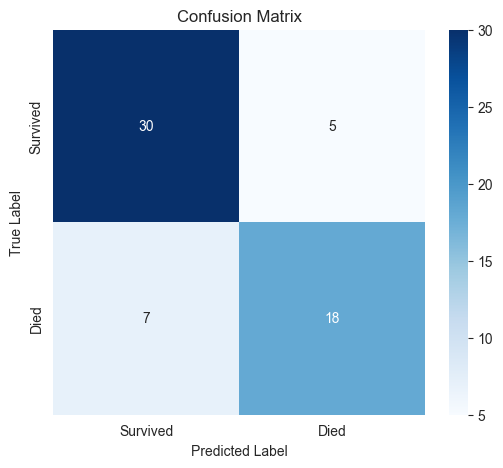


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        35
           1       0.78      0.72      0.75        25

    accuracy                           0.80        60
   macro avg       0.80      0.79      0.79        60
weighted avg       0.80      0.80      0.80        60

[[30  5]
 [ 7 18]]

==================== GB ====================


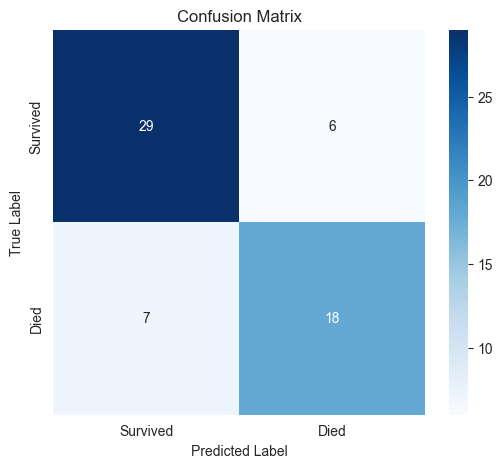


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        35
           1       0.75      0.72      0.73        25

    accuracy                           0.78        60
   macro avg       0.78      0.77      0.78        60
weighted avg       0.78      0.78      0.78        60

[[29  6]
 [ 7 18]]

==================== xgb_model ====================


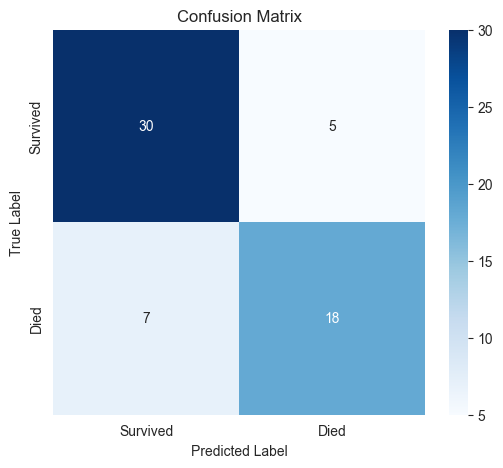


🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        35
           1       0.78      0.72      0.75        25

    accuracy                           0.80        60
   macro avg       0.80      0.79      0.79        60
weighted avg       0.80      0.80      0.80        60

[[30  5]
 [ 7 18]]


In [66]:
# Loop through each model in the dictionary
for name, model in models.items():
    print(f"\n==================== {name} ====================")

    # Train the model on the training data
    model.fit(x_train, y_train)

    # Predict the labels for the test set
    y_pred = model.predict(x_test)

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot the confusion matrix using a heatmap
    plt.figure(figsize=(6, 5))  # Set the figure size
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",  # Show numbers inside boxes
        xticklabels=["Survived", "Died"],       # Predicted label names
        yticklabels=["Survived", "Died"]        # True label names
    )
    plt.xlabel("Predicted Label")  # X-axis label
    plt.ylabel("True Label")       # Y-axis label
    plt.title("Confusion Matrix")  # Title of the plot
    plt.show()                     # Show the plot

    # Print the classification report (precision, recall, F1-score)
    print("\n🔹 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Also print the raw confusion matrix values
    print(cm)


In [67]:
# Split the dataset into training and testing sets (70% train, 30% test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,               # Features and target
    test_size=0.3,      # 30% of data for testing
    random_state=42     # Ensures reproducibility of the split
)

In [68]:
x_train = x_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [69]:
# Selecting top 3 important features based on feature importance analysis
# These features contribute the most to the model's prediction
x_train = x_train[['time', 'serum_creatinine', 'ejection_fraction']]
x_test = x_test[['time', 'serum_creatinine', 'ejection_fraction']]

In [70]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
x_train_scaled = scaler.fit_transform(x_train)

# Convert the scaled array back to a DataFrame with appropriate column names
x_train = pd.DataFrame(x_train_scaled, columns=['time', 'serum_creatinine', 'ejection_fraction'])

# View the scaled training data
x_train

,time,serum_creatinine,ejection_fraction
0,0.917167,-0.513224,-1.161762
1,-0.866991,-0.044003,-1.161762
2,0.865825,-0.278614,-0.295518
3,-1.329076,-0.513224,1.003848
4,-1.534447,-0.747834,-0.035644
...,...,...,...
204,0.493590,-0.513224,0.137604
205,-0.802813,-0.747834,-0.295518
206,-0.584607,0.190607,0.570726
207,1.417759,0.894437,-0.728640


In [71]:
x_test = scaler.transform(x_test)

x_test = pd.DataFrame(x_test, columns=x_train.columns)

x_test

,time,serum_creatinine,ejection_fraction
0,1.494773,2.184792,0.137604
1,1.366416,-0.747834,-0.295518
2,-0.058344,-0.278614,-0.728640
3,-1.585789,2.184792,-0.295518
4,-0.764306,-0.044003,0.137604
...,...,...,...
85,-0.340729,-0.090925,0.137604
86,-0.789977,-0.513224,-0.295518
87,-1.547282,0.190607,1.003848
88,-1.585789,2.184792,-0.035644


In [72]:
x_train = x_train.to_numpy()
y_train = y_train.to_numpy()
x_tes= x_test.to_numpy()
y_tes = y_test.to_numpy()

In [73]:
# splinting data to train and eval
x_test, x_eval, y_test, y_eval = train_test_split(
    x_tes, y_tes, test_size=0.5, random_state=42
)

In [74]:
x_test.shape , x_eval.shape , y_test.shape , y_eval.shape

((45, 3), (45, 3), (45,), (45,))

In [75]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),  
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  
])

C:\Users\singh\OneDrive\Documents\Desktop\Project\Heart faliure prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [77]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_eval, y_eval),
    epochs=10,
    batch_size=15
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6938 - loss: 0.6553 - val_accuracy: 0.6667 - val_loss: 0.6023
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7368 - loss: 0.6008 - val_accuracy: 0.6667 - val_loss: 0.5577
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7512 - loss: 0.5631 - val_accuracy: 0.6889 - val_loss: 0.5239
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7608 - loss: 0.5028 - val_accuracy: 0.7111 - val_loss: 0.4946
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7847 - loss: 0.4728 - val_accuracy: 0.6889 - val_loss: 0.4728
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7895 - loss: 0.4560 - val_accuracy: 0.6889 - val_loss: 0.4596
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8230 - loss: 0.4095 - val_accuracy: 0.6889 - val_loss: 0.4466
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8325 - loss: 0.4016 - val_accuracy: 0.6667 - va

In [78]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_eval, y_eval),
    epochs=10,
    batch_size=15
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.3639 - val_accuracy: 0.6667 - val_loss: 0.4375
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.3521 - val_accuracy: 0.6889 - val_loss: 0.4313
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8565 - loss: 0.3581 - val_accuracy: 0.6889 - val_loss: 0.4274
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8565 - loss: 0.3278 - val_accuracy: 0.6889 - val_loss: 0.4303
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.3324 - val_accuracy: 0.6889 - val_loss: 0.4341
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8421 - loss: 0.3327 - val_accuracy: 0.6889 - val_loss: 0.4335
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8517 - loss: 0.3312 - val_accuracy: 0.6889 - val_loss: 0.4350
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8517 - loss: 0.3376 - val_accuracy: 0.6889 - va

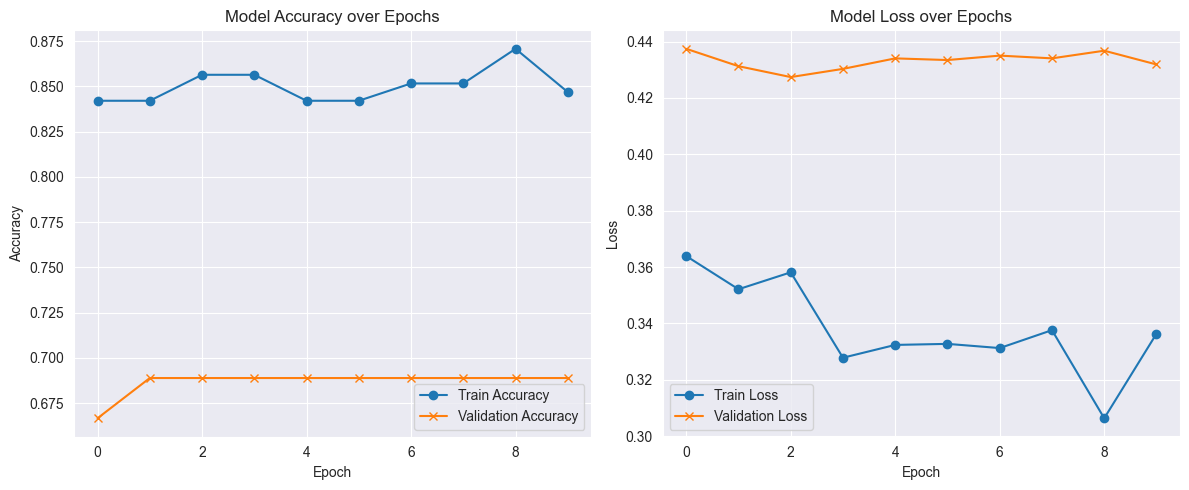

In [79]:
# ===  Accuracy ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ===  Loss ===
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [80]:
def evaluate_model(model, x, y, name=""):
    preds = np.round(model.predict(x)).astype("int32")
    acc = accuracy_score(y, preds)

    print(f"\n{name} Accuracy:", acc)
    print("Confusion Matrix:")
    print(confusion_matrix(y, preds))
    print("Classification Report:")
    print(classification_report(y, preds))

In [81]:
evaluate_model(model, x_train, y_train, "Train")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Train Accuracy: 0.8803827751196173
Confusion Matrix:
[[135  15]
 [ 10  49]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       150
           1       0.77      0.83      0.80        59

    accuracy                           0.88       209
   macro avg       0.85      0.87      0.86       209
weighted avg       0.88      0.88      0.88       209



In [82]:
y.value_counts()


DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [83]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i : weights[i] for i in range(len(weights))}

history = model.fit(
    x_train, y_train,
    validation_data=(x_eval, y_eval),
    epochs=30,  # increase for better learning
    batch_size=15,
    class_weight=class_weights
)


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8469 - loss: 0.3946 - val_accuracy: 0.7556 - val_loss: 0.4185
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8182 - loss: 0.3571 - val_accuracy: 0.8000 - val_loss: 0.4312
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8086 - loss: 0.3492 - val_accuracy: 0.8222 - val_loss: 0.4328
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8278 - loss: 0.3422 - val_accuracy: 0.8222 - val_loss: 0.4339
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8278 - loss: 0.3410 - val_accuracy: 0.8222 - val_loss: 0.4276
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8278 - loss: 0.3375 - val_accuracy: 0.8222 - val_loss: 0.4161
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8469 - loss: 0.3437 - val_accuracy: 0.8222 - val_loss: 0.4166
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8325 - loss: 0.3366 - val_accuracy: 0.8222 - va

In [84]:
evaluate_model(model, x_eval, y_eval, "Validation")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Validation Accuracy: 0.8
Confusion Matrix:
[[24  6]
 [ 3 12]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        30
           1       0.67      0.80      0.73        15

    accuracy                           0.80        45
   macro avg       0.78      0.80      0.78        45
weighted avg       0.81      0.80      0.80        45



In [85]:
evaluate_model(model, x_test, y_test, "Test")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Test Accuracy: 0.8
Confusion Matrix:
[[18  5]
 [ 4 18]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        23
           1       0.78      0.82      0.80        22

    accuracy                           0.80        45
   macro avg       0.80      0.80      0.80        45
weighted avg       0.80      0.80      0.80        45

